In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np

from hepattn.experiments.odd.performance.performance import Performance, PerformanceConfig
from hepattn.experiments.odd.performance.plot_helper import PlotHelper

In [3]:
!pip install atlas-ftag-tools

Defaulting to user installation because normal site-packages is not writeable


In [3]:
cd /storage/agrp/barakma/hepattn/

/storage/agrp/barakma/hepattn


In [30]:
config_dict = {
    "truth_path": "/storage/agrp/barakma/PileupODD/data/ttbar_pu0",
    "networks": [
        {
            "name": "oddflow",
            "path": "/storage/agrp/barakma/hepattn/src/hepattn/experiments/odd/logs/odd_pflow_v1_clic_arch_20260128-T131927/ckpts/epoch=119-val_loss=4.43505__test.root",
            "network_type": "mpflow_proxy",
            "ind_threshold": 0.65,
        },
        #{
        #    "name": "hgpflow",
        #    "path": "/storage/agrp/nilotpal/HGPFlow_v2/experiments/hgpflow_v2/clicxminixbig1x2xs2xxxds7kirm1yo/inference/ee_qq_new/pred_test_p8_ee_qq_ecm380_20k_seg_bw0.3_nocut_merged.root",
        #    "network_type": "hgpflow_proxy",
        #    "ind_threshold": 0.65,
        #},
        #{
        #    "name": "mlpf",
        #    "path": "/srv01/agrp/dmitrykl/projects/mlpf/particleflow/experiments/pyg-clic-my_20250726_155449_087474/test/preds_common_checkpoint-21-2.657597/batch_size",
        #    "network_type": "mlpf",
        #},
    ],
}

In [31]:
config = PerformanceConfig.from_dict(config_dict)

In [32]:
perf_obj = Performance(config)

Computing mpflow mass...: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████| 4000/4000 [00:00<00:00, 17864.81it/s]


E, pT will be scaled by 1
Number of events after filtering: 4000


Computing particle class...: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 4000/4000 [00:00<00:00, 22782.32it/s]


In [33]:
perf_obj.data['oddflow']['event_number']

array([86000, 86001, 86002, ..., 31052, 31053, 31054], shape=(4000,))

In [34]:
perf_obj.data['oddflow']['pt']

array([array([ 1.1885661 ,  3.3458078 , 37.192776  ,  3.0521815 , 10.400185  ,
               4.3075676 ,  5.016155  ,  2.772044  ,  2.2522092 ,  2.2522092 ,
               1.0162859 ,  2.5053885 ,  1.3743328 ,  7.0235596 ,  0.71216834,
              11.486264  ,  2.0125182 , 26.14619   ,  2.2522092 ,  1.1885661 ,
               0.85748416, 49.02433   ,  1.7863041 ,  1.7863041 ,  5.7786717 ,
               1.3743328 ,  0.46198028,  0.85748416,  1.1885661 ,  1.1885661 ,
               1.1885661 ,  3.9735014 ,  3.3458078 ,  1.3743328 ,  1.5735774 ,
               4.655116  ,  4.655116  , 24.493841  ,  3.3458078 ,  3.3458078 ,
               1.3743328 ,  1.7863041 ,  1.5735774 ,  1.7863041 ,  1.3743328 ,
               3.3458078 , 10.936483  , 12.626286  ,  1.5735774 ,  2.5053885 ,
               4.655116  ,  1.7863041 ,  1.3743328 ,  1.5735774 ,  1.7863041 ,
               1.7863041 ,  1.0162859 , 26.99258   ,  8.872157  ,  1.1885661 ,
               2.5053885 ,  1.3743328 , 12.0495405 ,

In [35]:
perf_obj.reorder_and_find_intersection()

common event count: 4000


Filtering and reordering oddflow...: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:00<00:00, 7273.36it/s]


In [36]:
perf_obj.compute_jets(n_procs=20)

Jet clustering algorithm:  genkt
Jet clustering radius:  0.7
truth


Computing jets...: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:04<00:00,  4.24Chunk/s]


Computing jets for oddflow...


Computing jets...: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:09<00:00,  2.09Chunk/s]


In [37]:
perf_obj.hung_match_jets()
perf_obj.compute_event_features()
perf_obj.compute_jet_res_features(dr_cut=0.1, leading_n_jets=2, pt_min=10)

Matching jets...: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4000/4000 [00:00<00:00, 12993.72it/s]


In [38]:
from collections import defaultdict


def default_style_dict():
    return {
        "histtype": "step",
        "linewidth": 1,
    }


style_dict = defaultdict(default_style_dict)
style_dict["pandora"] = {
    "color": "gray",
    "alpha": 0.5,
    "histtype": "stepfilled",
}

In [39]:
plot_helper = PlotHelper(perf_obj, style_dict=style_dict)

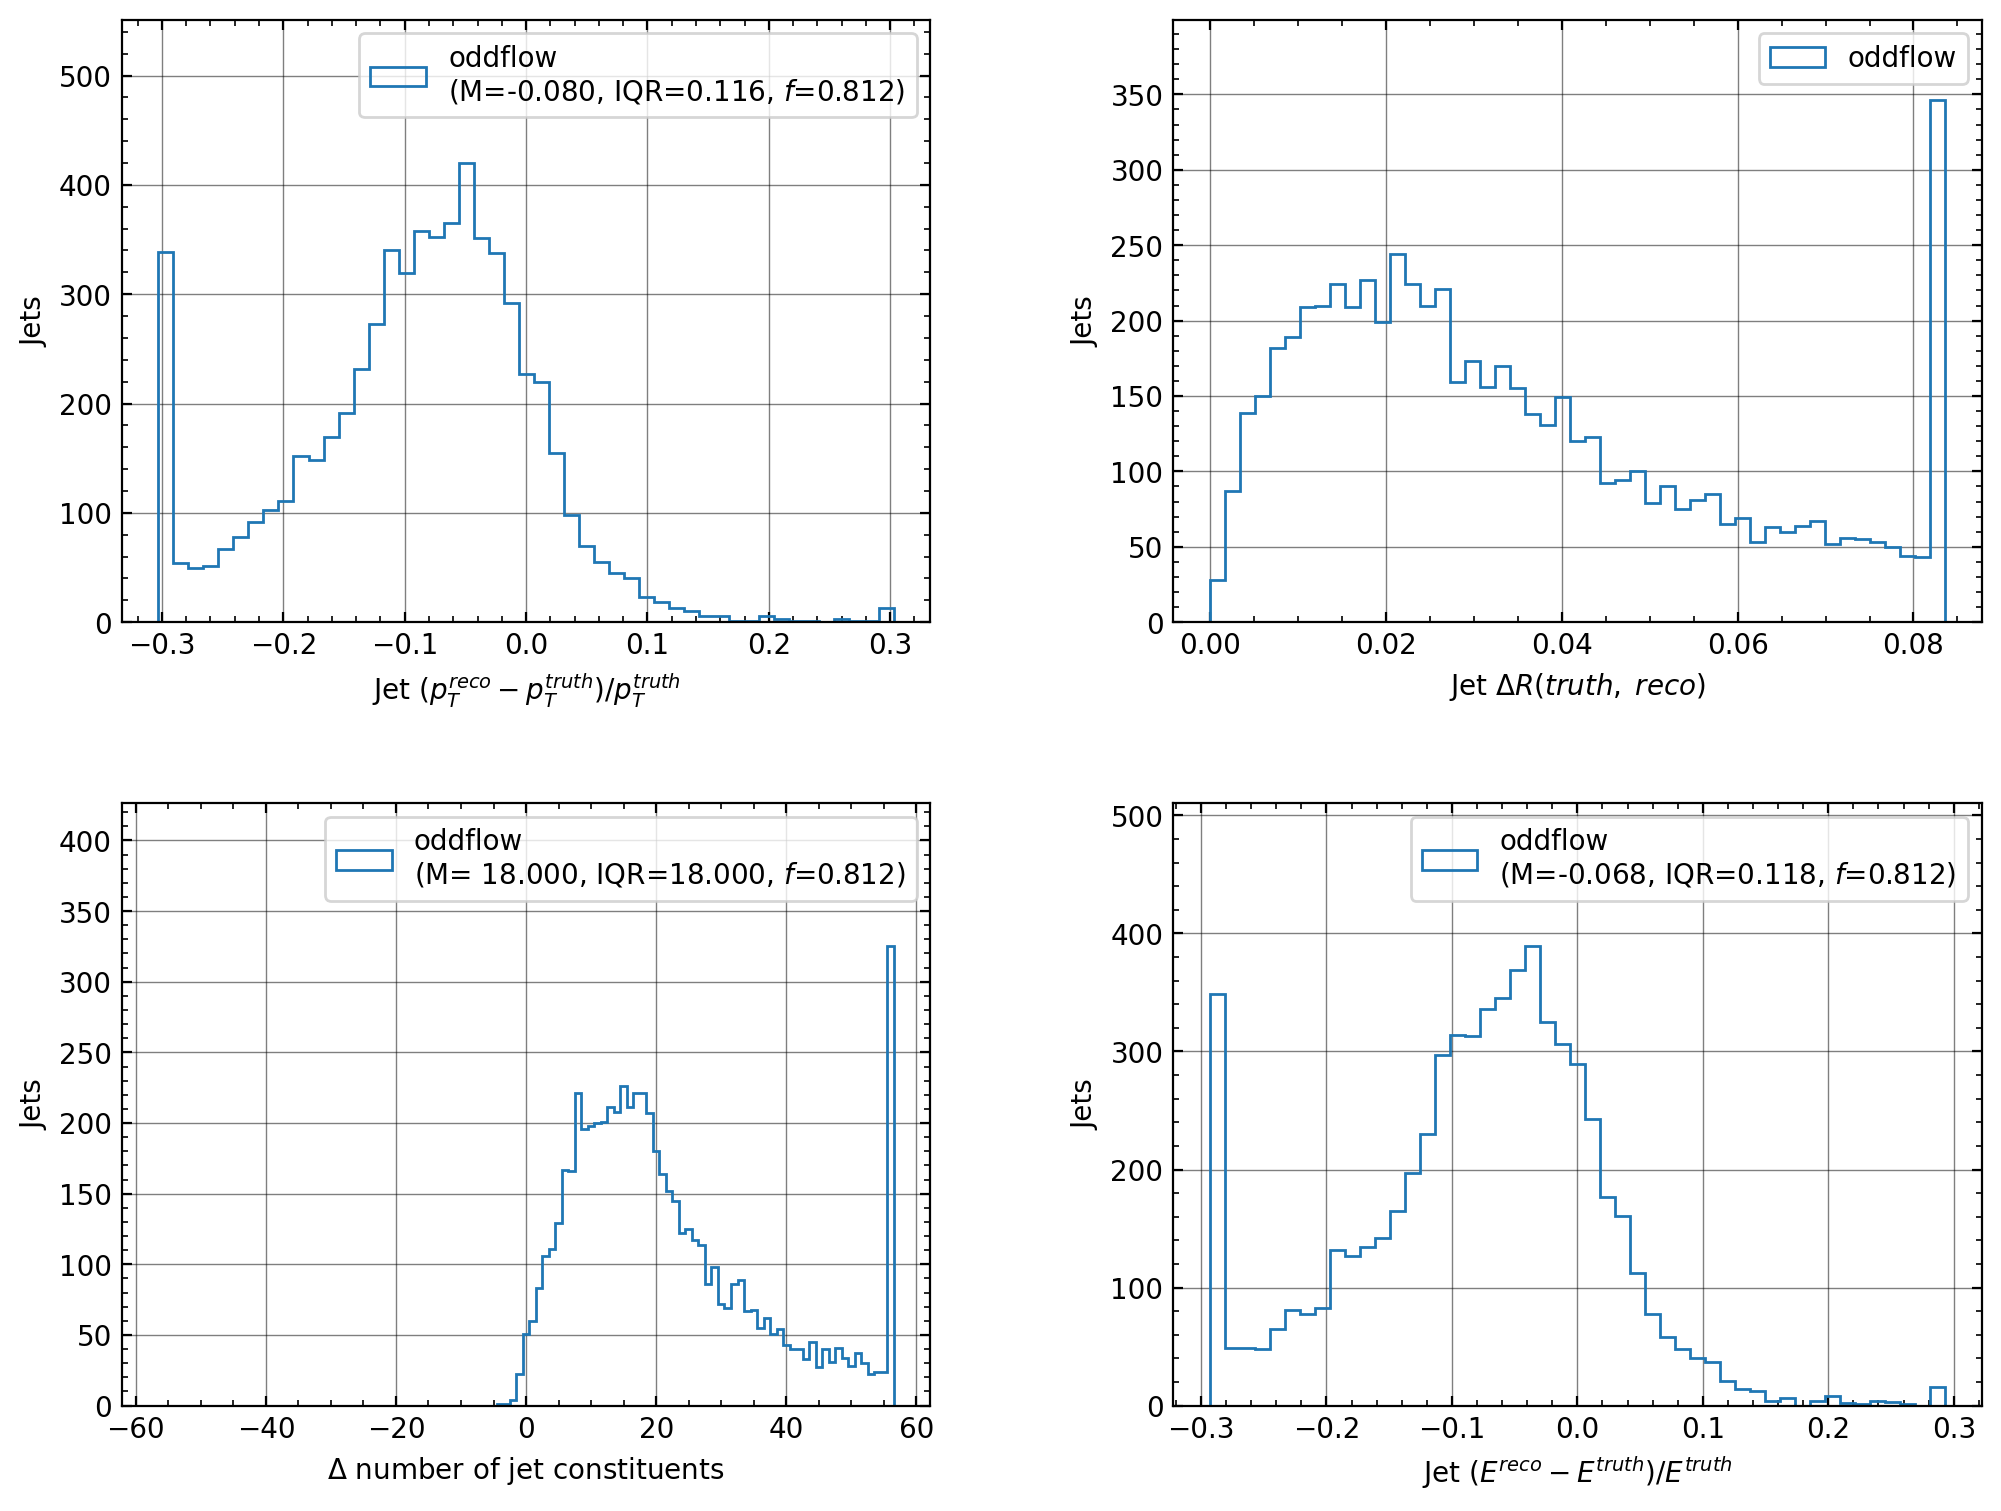

In [40]:
fig = plot_helper.plot_jet_residuals()

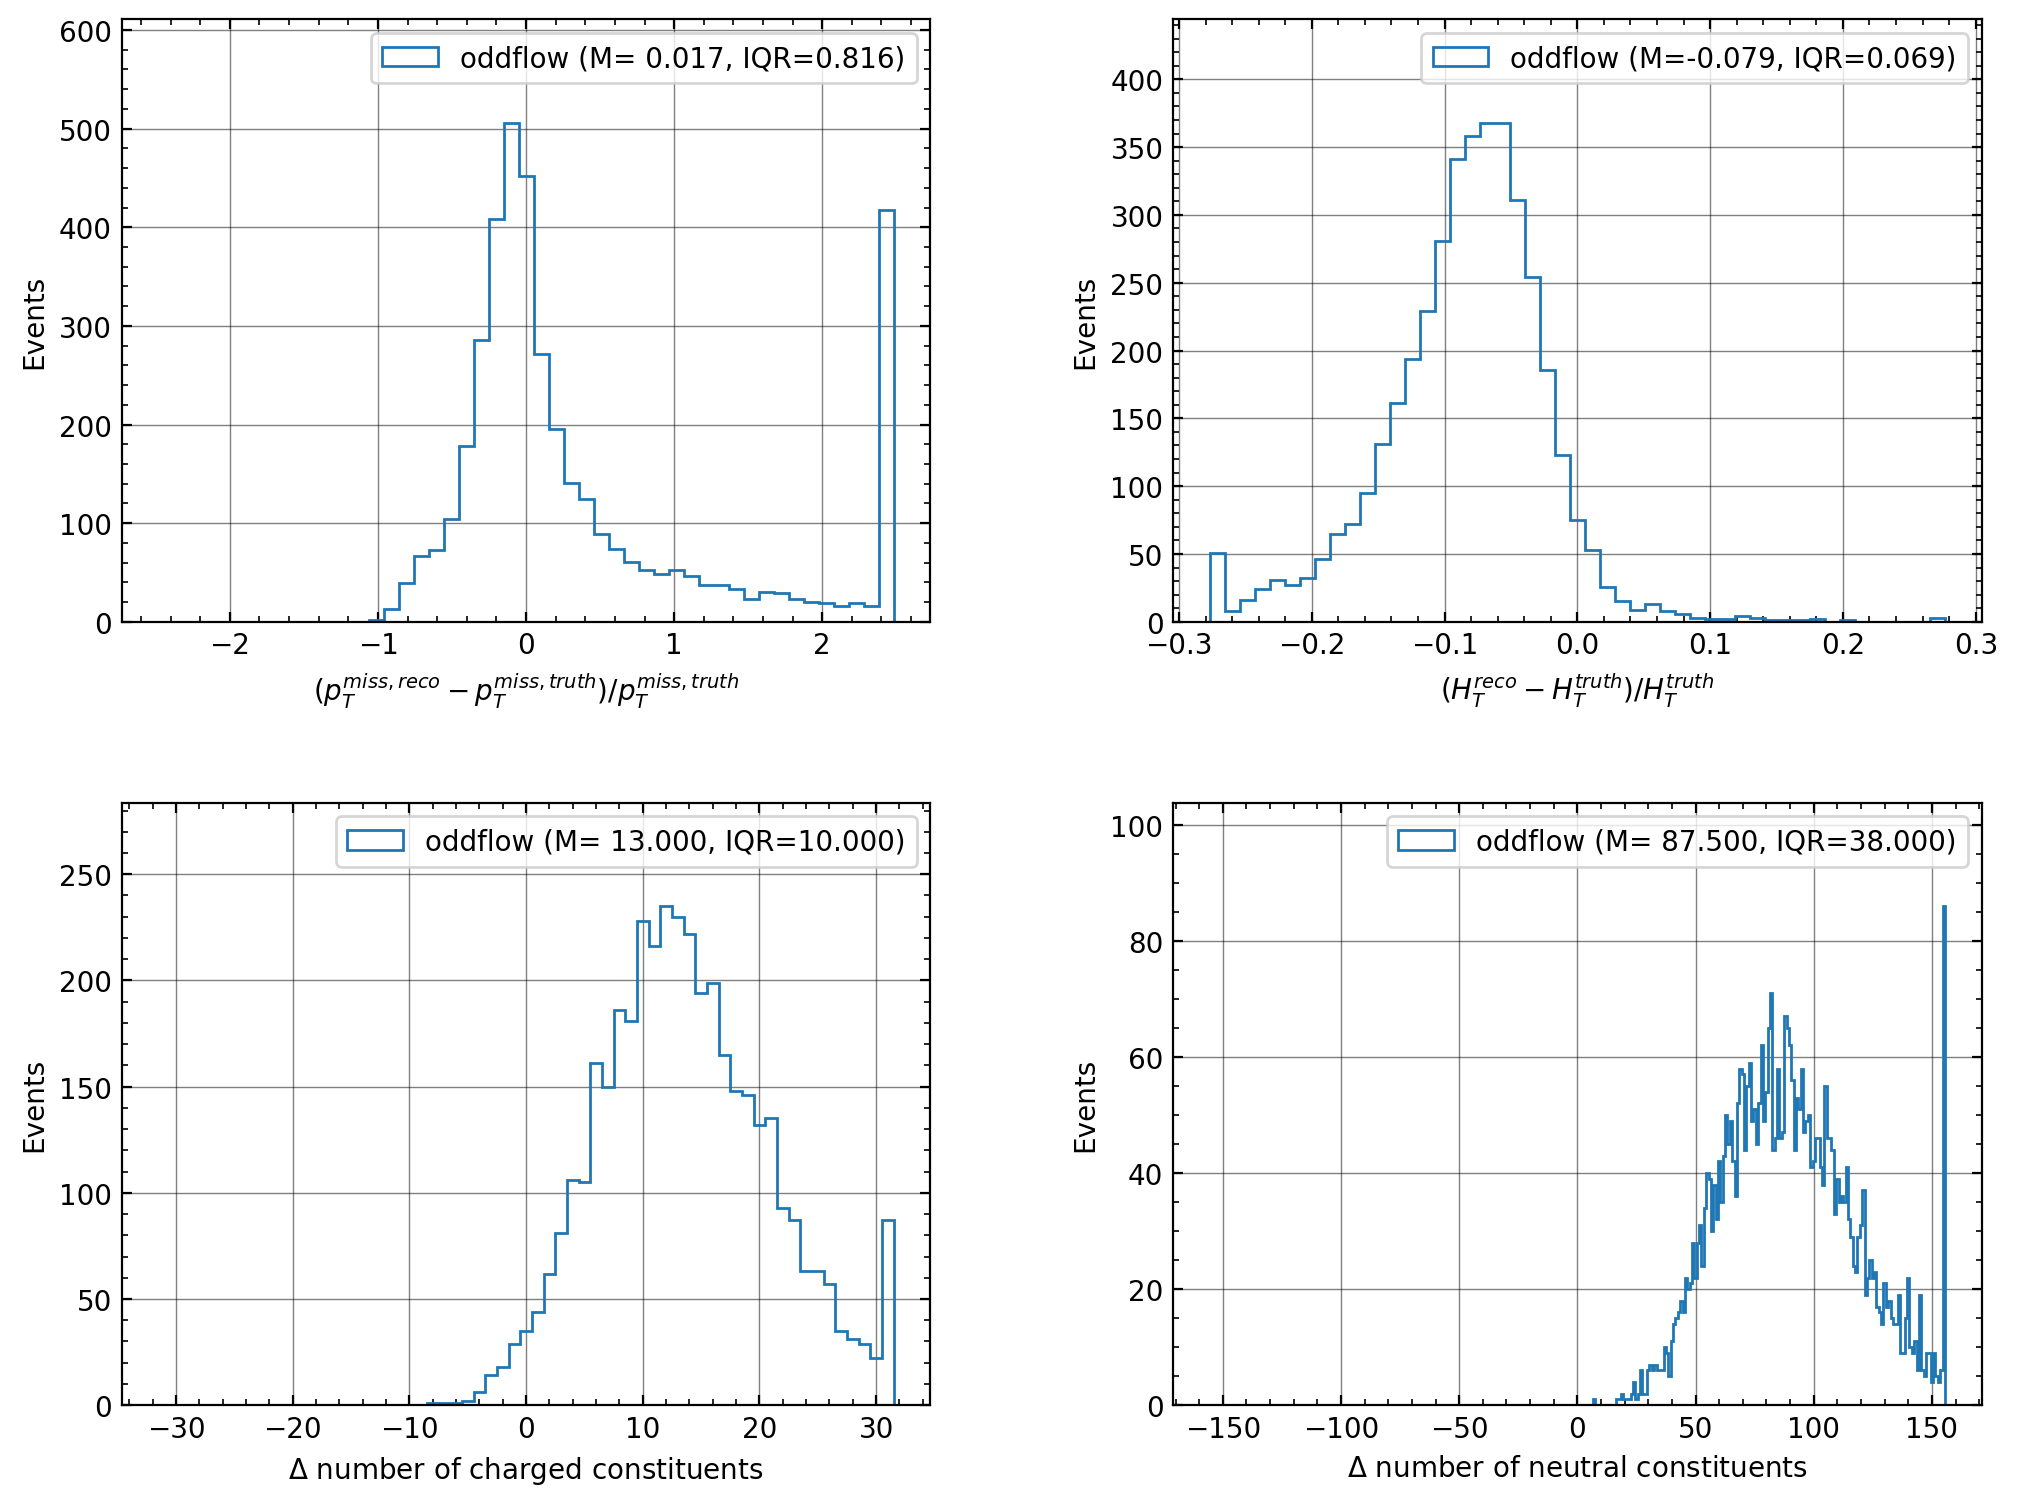

In [41]:
fig = plot_helper.plot_evt_res()

In [42]:
pt_bins = np.array([0, 20, 40, 60, 80, 100, 120, 140, 160, 180, 200])

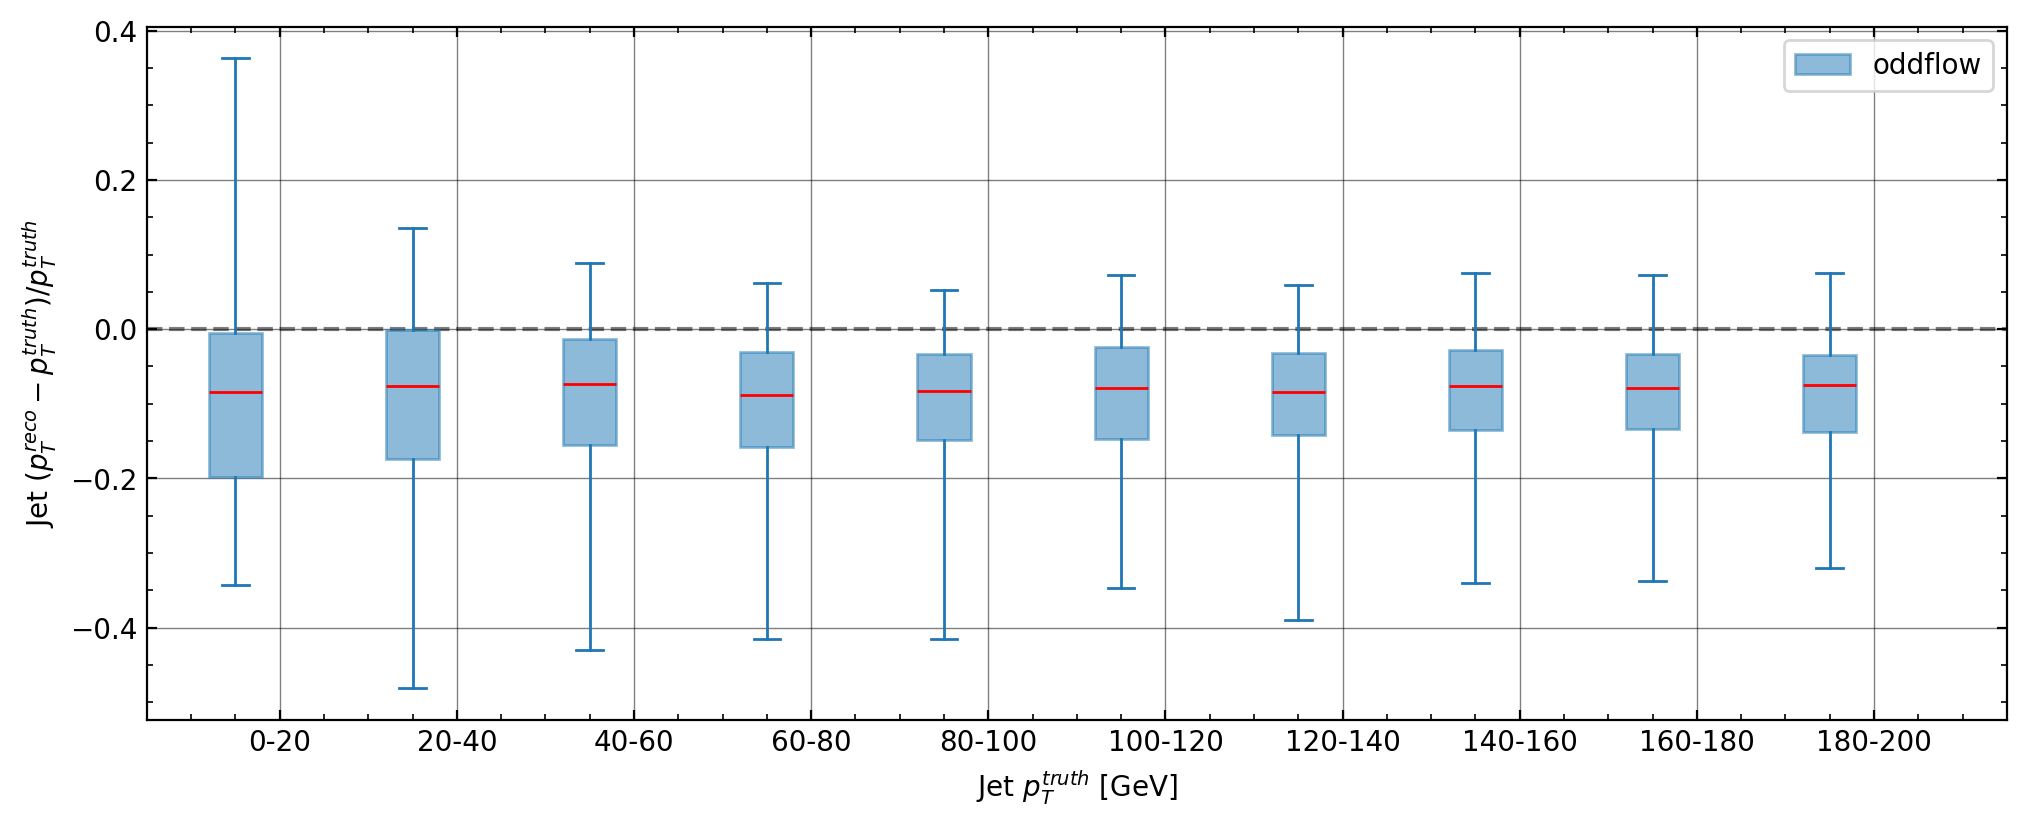

In [43]:
fig = plot_helper.plot_jet_res_boxplot(bins=pt_bins)

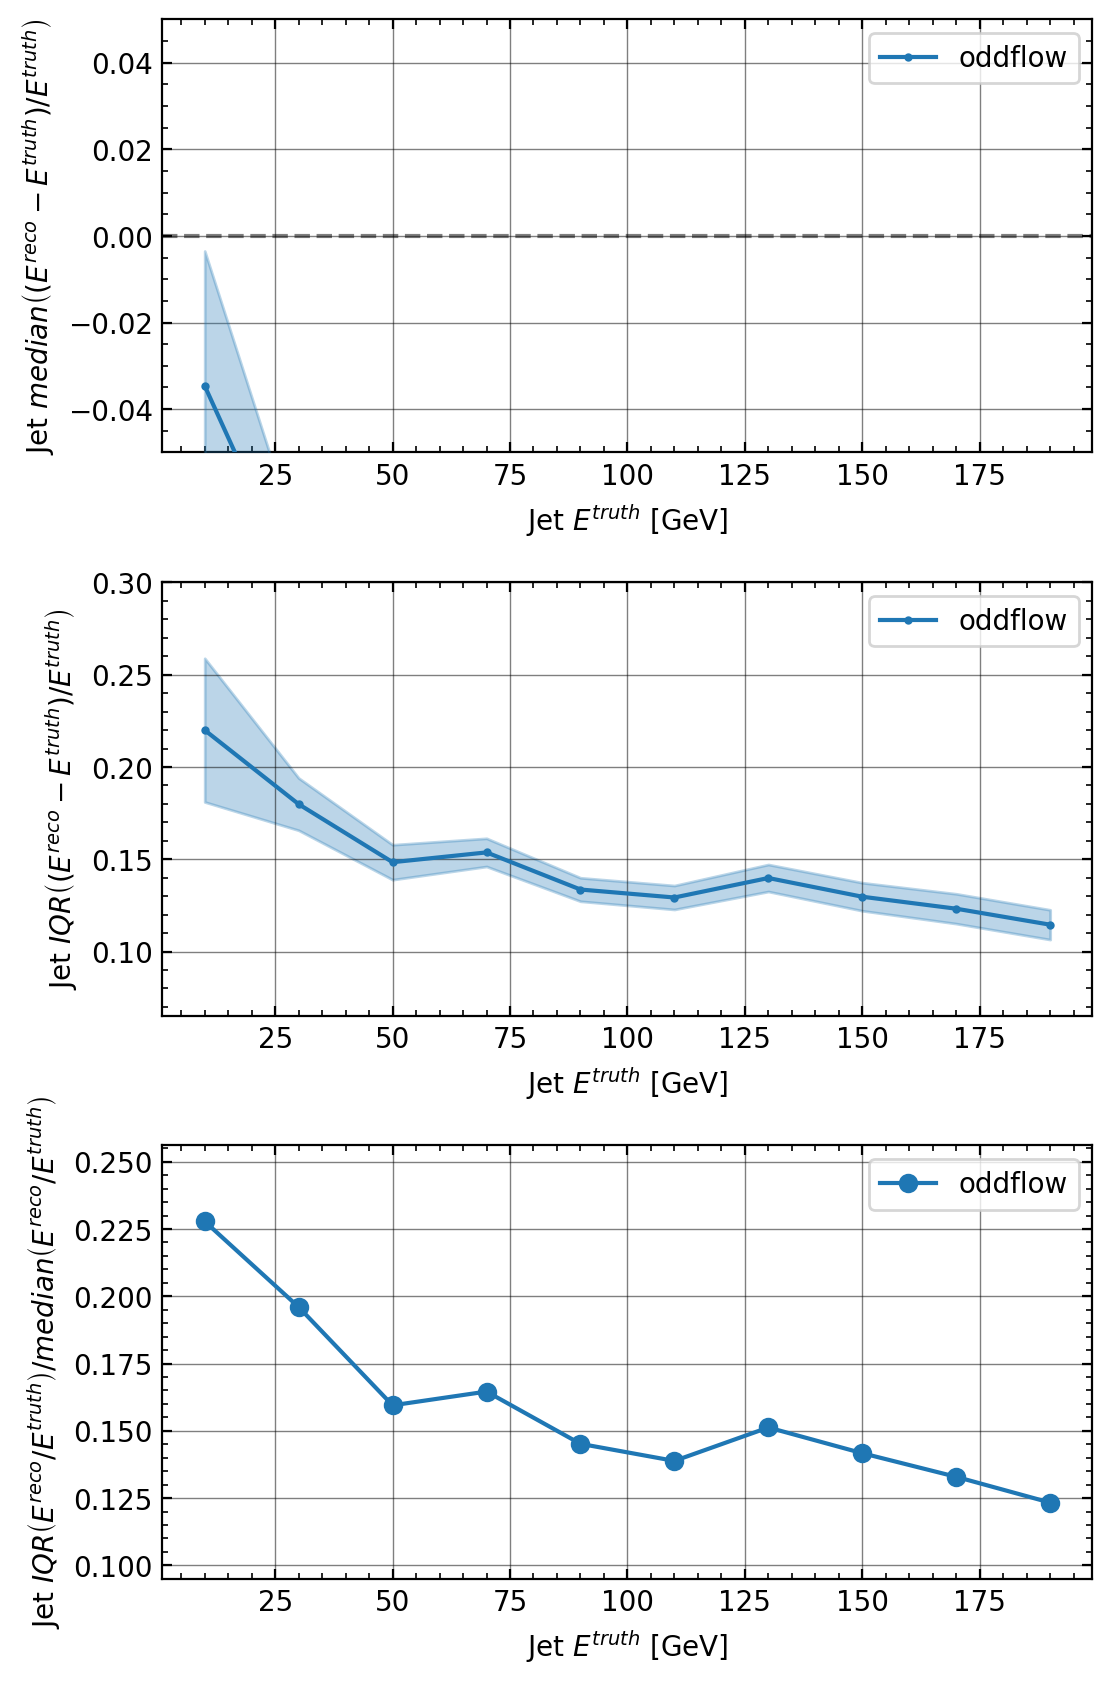

In [44]:
fig = plot_helper.plot_jet_response(pt_bins=pt_bins, use_energy=True)

In [45]:
perf_obj.hung_match_particles(flatten=True, return_unmatched=True)

Matching particles...:   9%|██████████▏                                                                                                    | 366/4000 [00:00<00:01, 1826.26it/s]

Matching particles...: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4000/4000 [00:02<00:00, 1861.17it/s]


/storage/agrp/barakma/hepattn/src/hepattn/experiments/odd/performance/plot_helper_particle.py:98: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(0, ax.get_ylim()[1] * (1 + len(residual_dict) * 0.23))


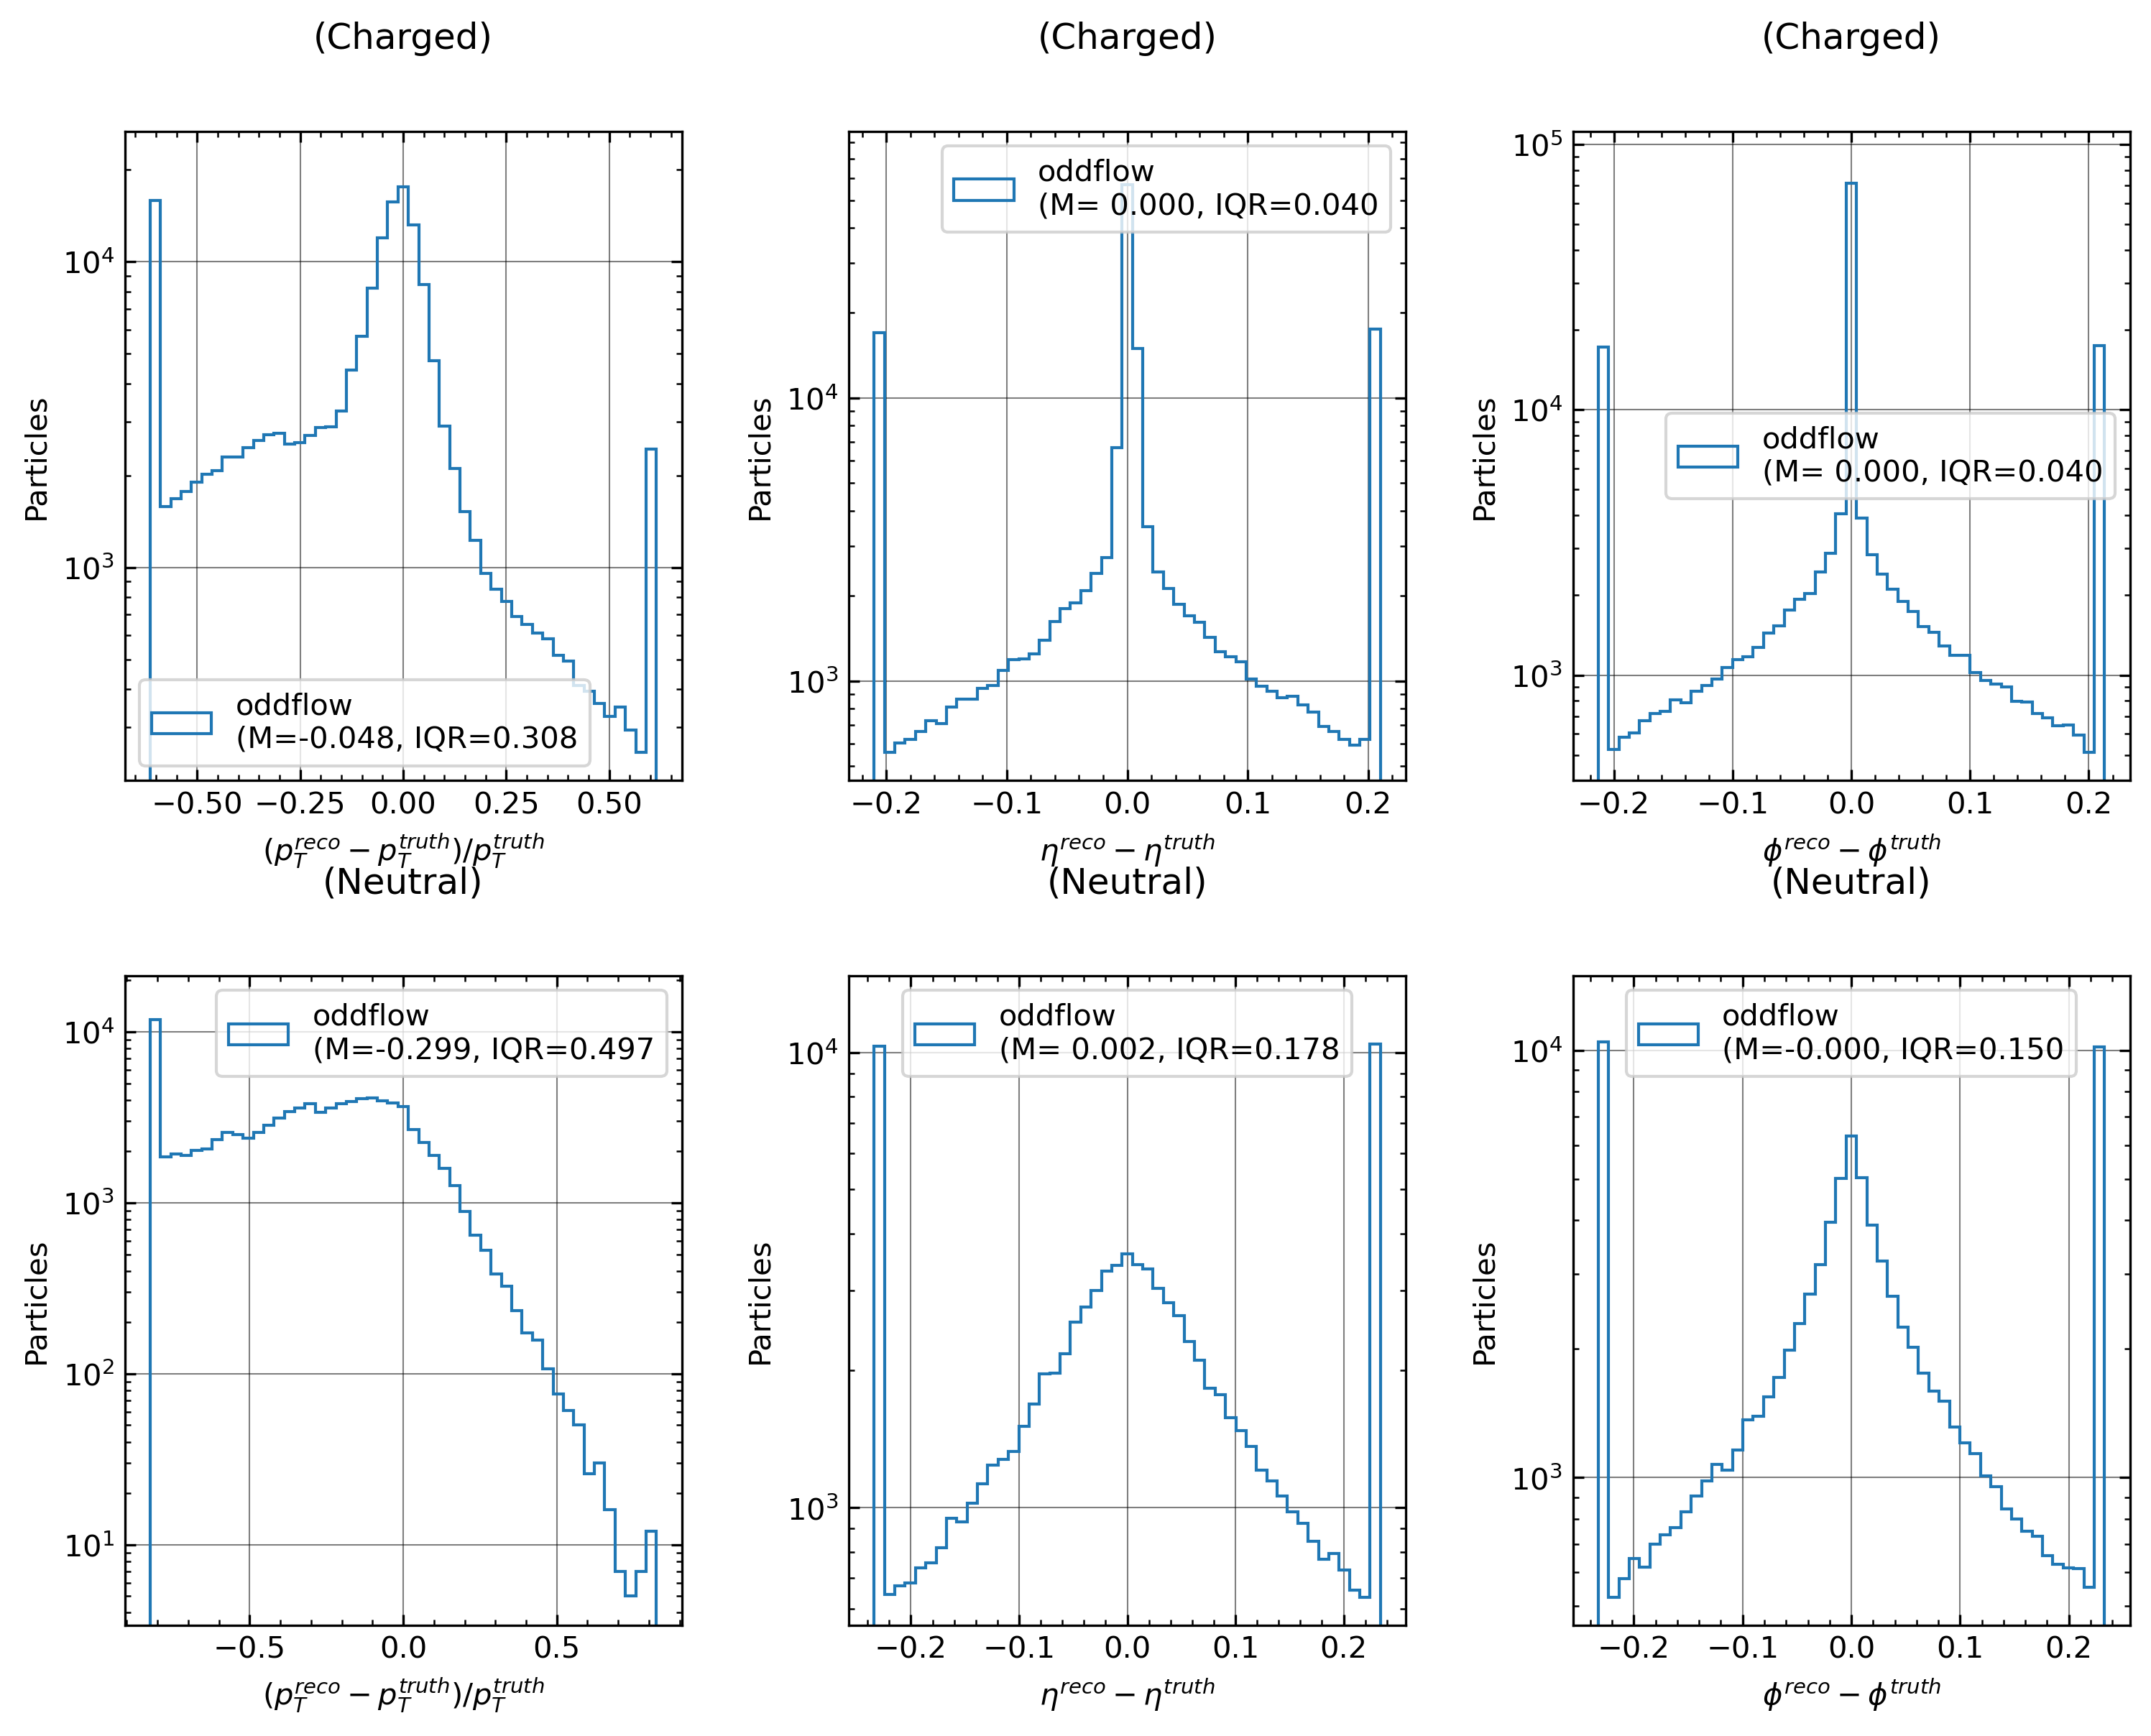

In [46]:
qs = {"Charged": {"pt": 90, "eta": 80, "phi": 80}, "Neutral": {"pt": 90, "eta": 80, "phi": 80}}
fig = plot_helper.plot_residuals(pt_relative=True, log_y=True, qs=qs)

In [47]:
qs = {"Neutral hadron": {"pt": 98, "eta": 75, "phi": 75}, "Photon": {"pt": 99, "eta": 90, "phi": 90}}
fig = plot_helper.plot_residuals_neutrals(pt_relative=True, log_y=True, qs=qs)

/storage/agrp/barakma/hepattn/src/hepattn/experiments/odd/performance/plot_helper_particle.py:192: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(0, ax.get_ylim()[1] * (1 + len(residual_dict) * 0.23))


In [50]:
eff_fr_colors = {
    "oddflow": {
        "neut had": "mediumseagreen",
        "photon": "tomato",
    },

}

bck={    "hgpflow": {
        "neut had": "steelblue",
        "photon": "darkorange",
    },
    "pandora": {
        "neut had": "dodgerblue",
        "photon": "goldenrod",
    },
    "mlpf": {
        "neut had": "crimson",
        "photon": "darkviolet",
    },}

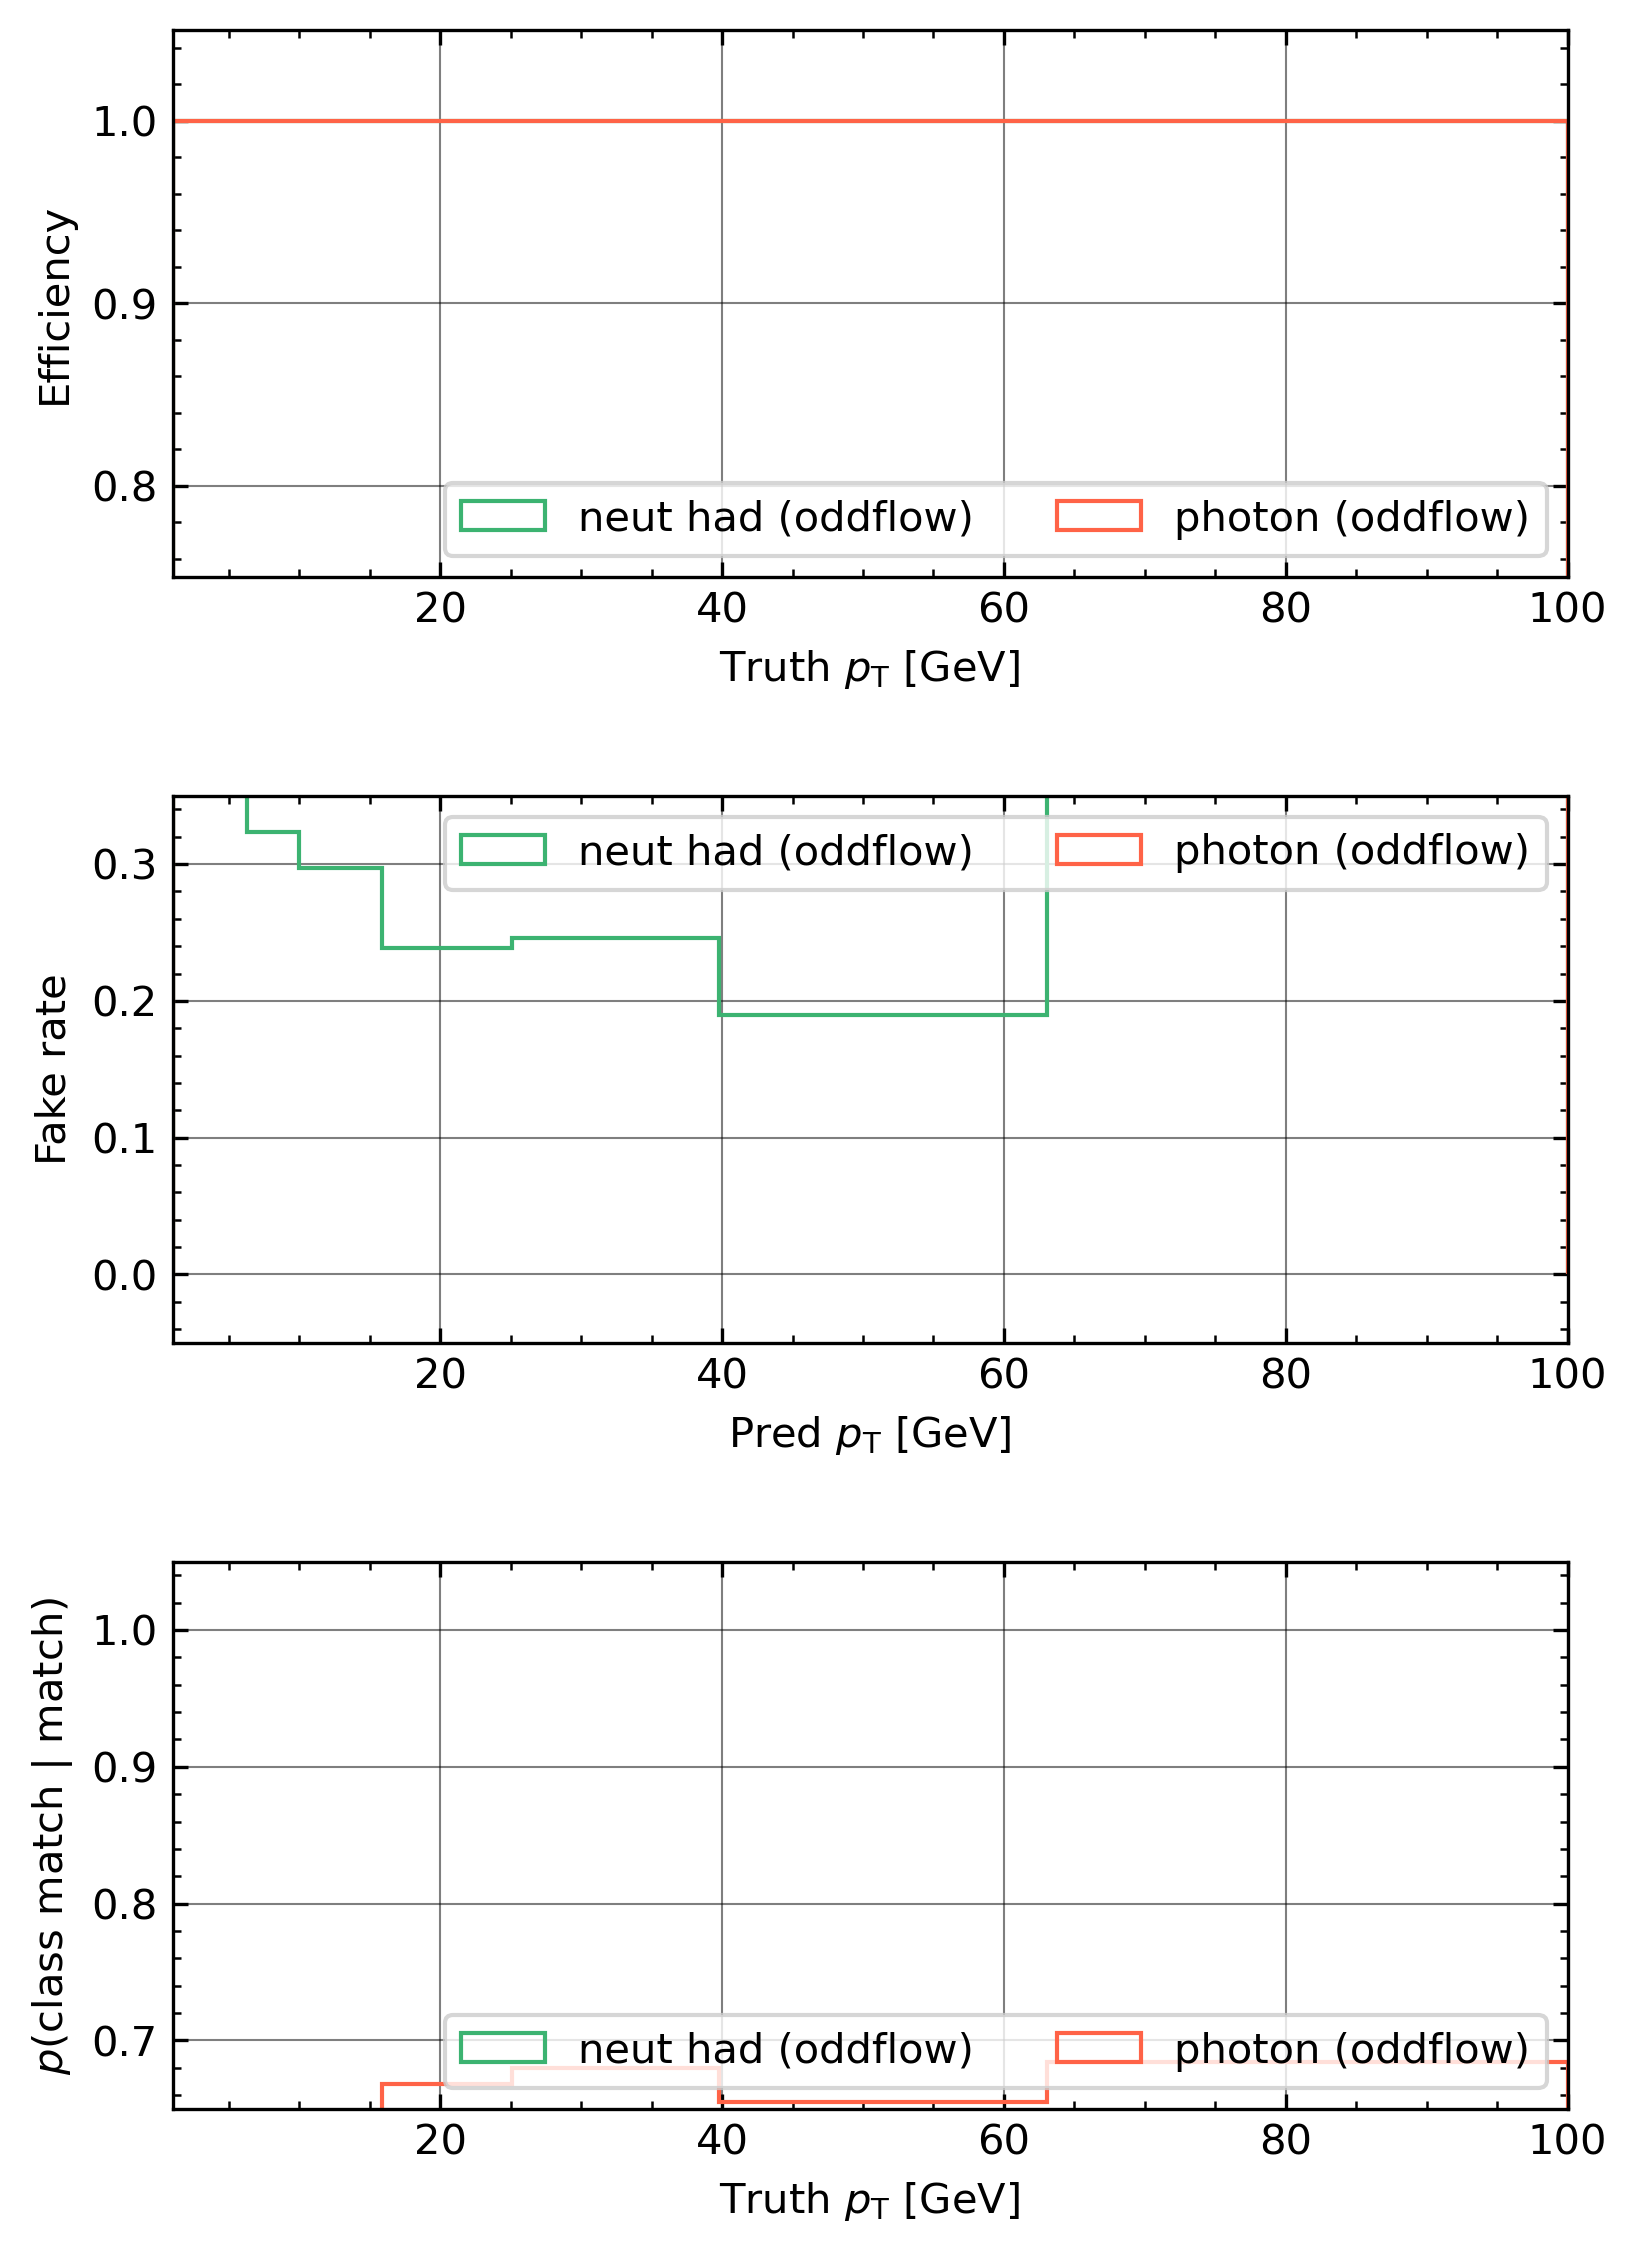

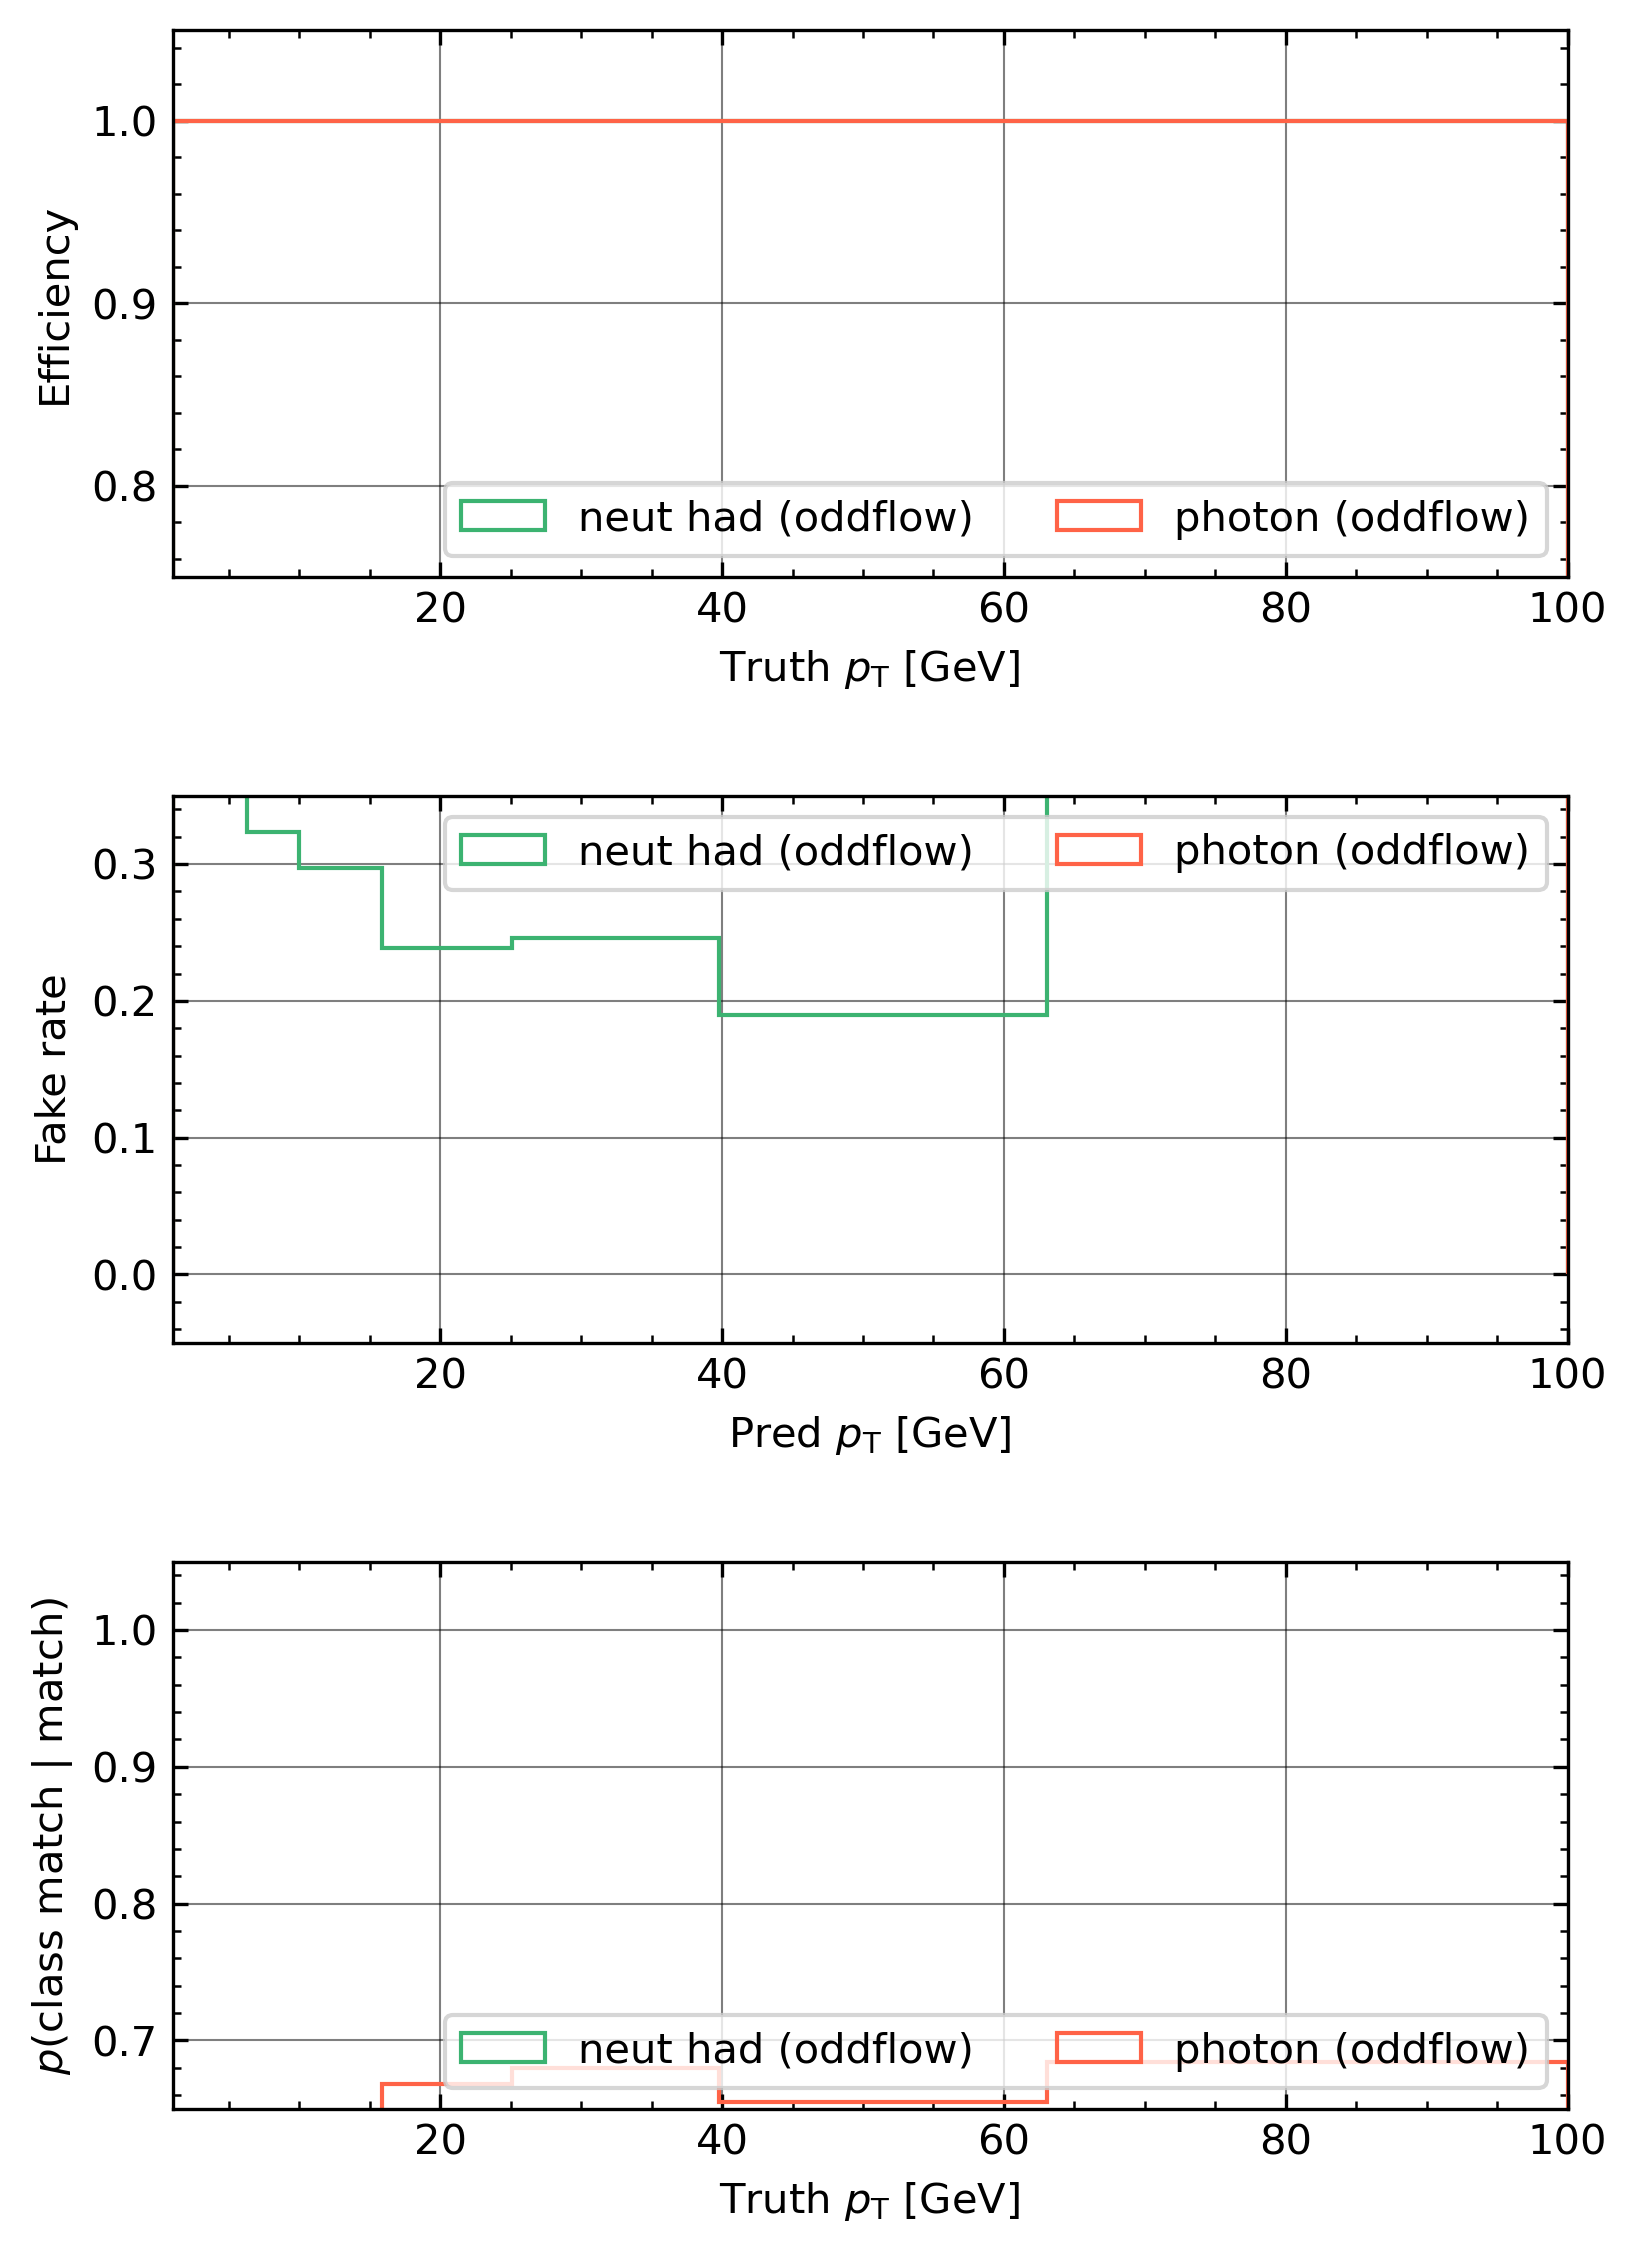

In [51]:
plot_helper.plot_eff_fr_purity(eff_fr_colors)